# Mapping the self-similar-residual $\to$ matter-suppression calibration across feedback space

The "money plot" in `tsz_wl_calibration.ipynb` shows that, for **CV halos at fiducial
feedback**, a halo's deviation from the self-similar $Y$–$M$ relation,
$\Delta_{\rm SS}\equiv\log_{10}(Y_{200}/Y_{200}^{\rm SS})$ with
$Y_{200}^{\rm SS}=c_0 M_{200}^{5/3}$, predicts its **matter-power suppression**
$P_{\rm hydro}/P_{\rm DMO}$ at $k\approx10.4\,h/{\rm Mpc}$ (BIND slope $\alpha\approx+0.17$,
$\sigma_{\rm int}\approx0.086$).

Here we exploit BIND's ability to generate at **any** point in parameter space: the same
~1111 CV halos were regenerated across a **256-point Sobol grid in the 30 astrophysical
parameters** (cosmology fixed at the CV fiducial), via `sobol_ss_generation.py`. We refit the
$\Delta_{\rm SS}\!\to\!$suppression relation at every grid point and ask **which feedback knobs
tune the slope $\alpha$ (how strongly $Y$-deviation predicts suppression), the zero-point
$\beta$ (the typical suppression at the median deviation), and the intrinsic scatter
$\sigma_{\rm int}$.**

> Common random numbers: each design point reuses the same per-halo flow-matching noise, so
> design-to-design differences reflect parameters, not resampling noise.

## 0. Setup & load the Sobol cube

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import spearmanr

plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
                     'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.grid': False})

CUBE = Path('/mnt/home/mlee1/ceph/sobol_ss_cv/cube.npz')        # full 256-pt run
if not CUBE.exists():
    CUBE = Path('/mnt/home/mlee1/ceph/sobol_ss_cv_dev/cube.npz')  # dev preview
print('Reading', CUBE)
z = np.load(CUBE, allow_pickle=True)
OBS = z['obs']                       # (n_design, n_halo, n_obs)
OBS_NAMES = list(z['obs_names'])
logM = np.log10(z['M200'].astype(float))   # (n_halo,) fixed SS mass anchor (catalog M200)
design_norm = z['design_norm']             # (n_design, 30) Sobol box coords in [0,1]
astro_names = list(z['astro_names'])
n_design, n_halo, n_obs = OBS.shape
print(f'designs={n_design}  halos={n_halo}  obs={OBS_NAMES}')

# short labels for the classic CAMELS knobs; ParamName otherwise
SHORT = {'WindEnergyIn1e51erg': 'A_SN1', 'VariableWindVelFactor': 'A_SN2',
         'RadioFeedbackFactor': 'A_AGN1', 'RadioFeedbackReiorientationFactor': 'A_AGN2'}
PLAB = [SHORT.get(n, n) for n in astro_names]
iY = OBS_NAMES.index('Y200')
iS = OBS_NAMES.index('supp_k10')

FIG = Path('tsz_ss_sobol_figs'); FIG.mkdir(exist_ok=True)
def savefig(fig, name):
    for e in ('pdf', 'png'):
        fig.savefig(FIG / f'{name}.{e}')
    print('wrote', FIG / f'{name}.png')

Reading /mnt/home/mlee1/ceph/sobol_ss_cv/cube.npz
designs=256  halos=1111  obs=['Y200', 'T', 'S', 'P', 'f_gas', 'm_gen', 'supp_k10', 'supp_prof']


## 1. Per-design self-similar-residual fit

At each design point we (i) fit the self-similar normalization $c_0$ with the slope fixed to
$5/3$ ($\log_{10}c_0=\langle\log_{10}Y-\tfrac53\log_{10}M\rangle$; cosmology is fixed so the
$\Omega_b/\Omega_M$ factor is an absorbed constant), (ii) form $\Delta_{\rm SS}$, and (iii) fit
$S=\alpha(\Delta_{\rm SS}-{\rm pivot})+\beta+\mathcal N(0,\sigma_{\rm int})$ by maximum
likelihood with $\sigma_{\rm int}$ a free parameter — the same procedure as `fig_money`.

In [2]:
def _design_arrays(d, s_name='supp_k10'):
    # per-halo Delta_SS and suppression for one design (cosmo fixed -> no Omega factor)
    Y = OBS[d, :, iY]
    S = OBS[d, :, OBS_NAMES.index(s_name)]
    base = np.isfinite(logM) & np.isfinite(Y) & (Y > 0)
    lY = np.full_like(logM, np.nan); lY[base] = np.log10(Y[base])
    logc0 = float(np.nanmean(lY[base] - (5 / 3) * logM[base]))
    xdev = np.full_like(logM, np.nan); xdev[base] = lY[base] - (logc0 + (5 / 3) * logM[base])
    return xdev, S, logc0

def fit_one_design(d, s_name='supp_k10'):
    xdev, S, _ = _design_arrays(d, s_name)
    m = np.isfinite(xdev) & np.isfinite(S)
    if m.sum() < 5:
        return None
    x, y = xdev[m], S[m]
    piv = float(np.median(x)); xx = x - piv
    def nll(th):
        a, b, ls = th
        s2 = np.exp(2 * ls); r = y - (a * xx + b)
        return 0.5 * np.sum(np.log(2 * np.pi * s2) + r * r / s2)
    a0, b0 = np.polyfit(xx, y, 1); s0 = float(np.std(y - (a0 * xx + b0))) + 1e-6
    res = minimize(nll, [a0, b0, np.log(s0)], method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-7})
    a, b, ls = res.x
    return dict(alpha=float(a), beta=float(b), sigma_int=float(np.exp(ls)),
                pivot=piv, median_S=float(np.median(y)),
                spearman=float(spearmanr(x, y).correlation), n=int(m.sum()))

fits = [fit_one_design(d) for d in range(n_design)]
fit_df = pd.DataFrame(fits)
for c in ['alpha', 'beta', 'sigma_int', 'median_S', 'spearman']:
    v = fit_df[c].values
    print(f'{c:10s} range [{np.nanmin(v):+.3f}, {np.nanmax(v):+.3f}]   median {np.nanmedian(v):+.3f}')

alpha      range [-0.004, +0.240]   median +0.119
beta       range [+0.690, +1.345]   median +0.897
sigma_int  range [+0.064, +0.190]   median +0.089
median_S   range [+0.688, +1.322]   median +0.882
spearman   range [-0.040, +0.442]   median +0.236


## 2. The calibration moves across parameter space

The four panels show the actual $\Delta_{\rm SS}$–suppression scatter (colored by halo mass)
at the design points with the **extreme** fitted slope $\alpha$ and zero-point $\beta$ — i.e.
the corners of feedback space where the law is steepest/flattest and where suppression is
strongest/weakest.

wrote tsz_ss_sobol_figs/ss_money_panels.png


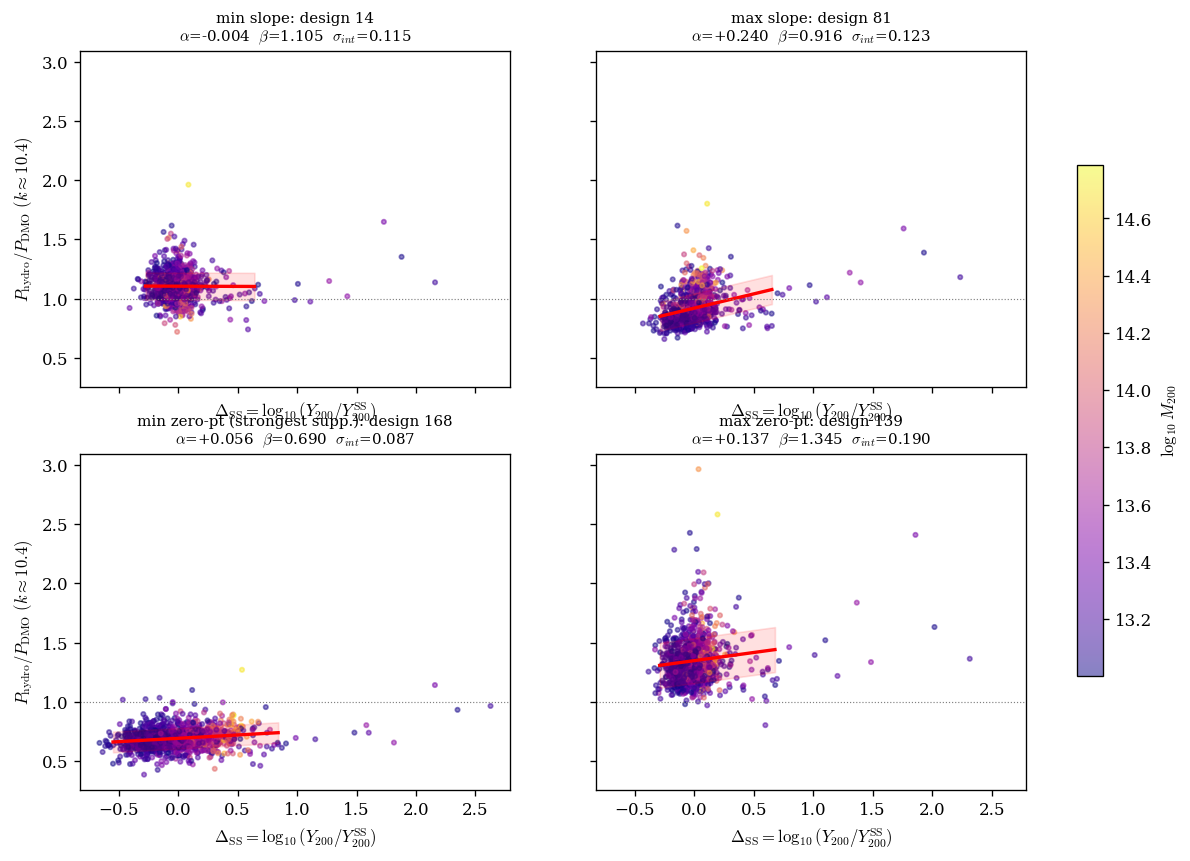

In [3]:
def render_money(ax, d):
    xdev, S, _ = _design_arrays(d)
    m = np.isfinite(xdev) & np.isfinite(S)
    f = fits[d]
    sc = ax.scatter(xdev[m], S[m], s=7, c=logM[m], cmap='plasma', alpha=0.5)
    xs = np.linspace(np.nanpercentile(xdev[m], 1), np.nanpercentile(xdev[m], 99), 60)
    ys = f['alpha'] * (xs - f['pivot']) + f['beta']
    ax.plot(xs, ys, 'r-', lw=2)
    ax.fill_between(xs, ys - f['sigma_int'], ys + f['sigma_int'], color='r', alpha=0.12)
    ax.axhline(1.0, color='0.5', lw=0.7, ls=':')
    ax.set_xlabel(r'$\Delta_{\rm SS}=\log_{10}(Y_{200}/Y_{200}^{\rm SS})$')
    return sc

order_a = np.argsort(fit_df['alpha'].values)
order_b = np.argsort(fit_df['beta'].values)
picks = [('min slope', order_a[0]), ('max slope', order_a[-1]),
         ('min zero-pt (strongest supp.)', order_b[0]), ('max zero-pt', order_b[-1])]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
sc = None
for ax, (lab, d) in zip(axes.ravel(), picks):
    sc = render_money(ax, d)
    f = fits[d]
    ax.set_title(f'{lab}: design {d}\n'
                 r'$\alpha$=%+.3f  $\beta$=%.3f  $\sigma_{int}$=%.3f'
                 % (f['alpha'], f['beta'], f['sigma_int']), fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel(r'$P_{\rm hydro}/P_{\rm DMO}\ (k\approx10.4)$')
fig.colorbar(sc, ax=axes, fraction=0.025, label=r'$\log_{10}M_{200}$')
savefig(fig, 'ss_money_panels'); plt.show()

## 3. Sensitivity — which feedback knobs tune the law?

We regress each fit parameter on the 30 (standardized) astro knobs. **Standardized regression
coefficients (SRC)** are the primary estimator (prior CAMELS-BIND scatter work showed the
population response is smooth/near-linear, so SRC is justified); the model-free **distance
correlation** is the cross-check. Bootstrap CIs are over the design points; a coefficient is
flagged significant when its 16–84% interval excludes zero.

In [4]:
def src_bootstrap(X, y, n_boot=500, rng=None):
    rng = rng or np.random.default_rng(0)
    X = np.asarray(X, float); y = np.asarray(y, float)
    m = np.all(np.isfinite(X), 1) & np.isfinite(y)
    X, y = X[m], y[m]
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12)
    ys = (y - y.mean()) / (y.std() + 1e-12)
    b = np.linalg.lstsq(Xs, ys, rcond=None)[0]
    r2 = 1 - np.sum((ys - Xs @ b) ** 2) / np.sum(ys ** 2)
    boots = np.empty((n_boot, X.shape[1]))
    for k in range(n_boot):
        i = rng.integers(0, len(ys), len(ys))
        boots[k] = np.linalg.lstsq(Xs[i], ys[i], rcond=None)[0]
    return b, np.percentile(boots, 16, 0), np.percentile(boots, 84, 0), float(r2)

def dcor(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    a = np.abs(x[:, None] - x[None, :]); b = np.abs(y[:, None] - y[None, :])
    A = a - a.mean(0) - a.mean(1)[:, None] + a.mean()
    B = b - b.mean(0) - b.mean(1)[:, None] + b.mean()
    dcov = np.sqrt(max((A * B).mean(), 0.0))
    dx = np.sqrt(max((A * A).mean(), 0.0)); dy = np.sqrt(max((B * B).mean(), 0.0))
    return float(dcov / np.sqrt(dx * dy)) if dx > 0 and dy > 0 else 0.0

TARGETS = ['alpha', 'beta', 'sigma_int', 'median_S']
SRC = np.full((len(PLAB), len(TARGETS)), np.nan)
SRC_lo = SRC.copy(); SRC_hi = SRC.copy(); R2 = {}
for j, t in enumerate(TARGETS):
    b, lo, hi, r2 = src_bootstrap(design_norm, fit_df[t].values)
    SRC[:, j], SRC_lo[:, j], SRC_hi[:, j] = b, lo, hi
    R2[t] = r2
    print(f'{t:10s} linear SRC R2 = {r2:.3f}')

alpha      linear SRC R2 = 0.557
beta       linear SRC R2 = 0.697


sigma_int  linear SRC R2 = 0.644
median_S   linear SRC R2 = 0.696


Heatmap of standardized drivers (annotated cells are significant at 16–84%):

wrote tsz_ss_sobol_figs/ss_src_heatmap.png


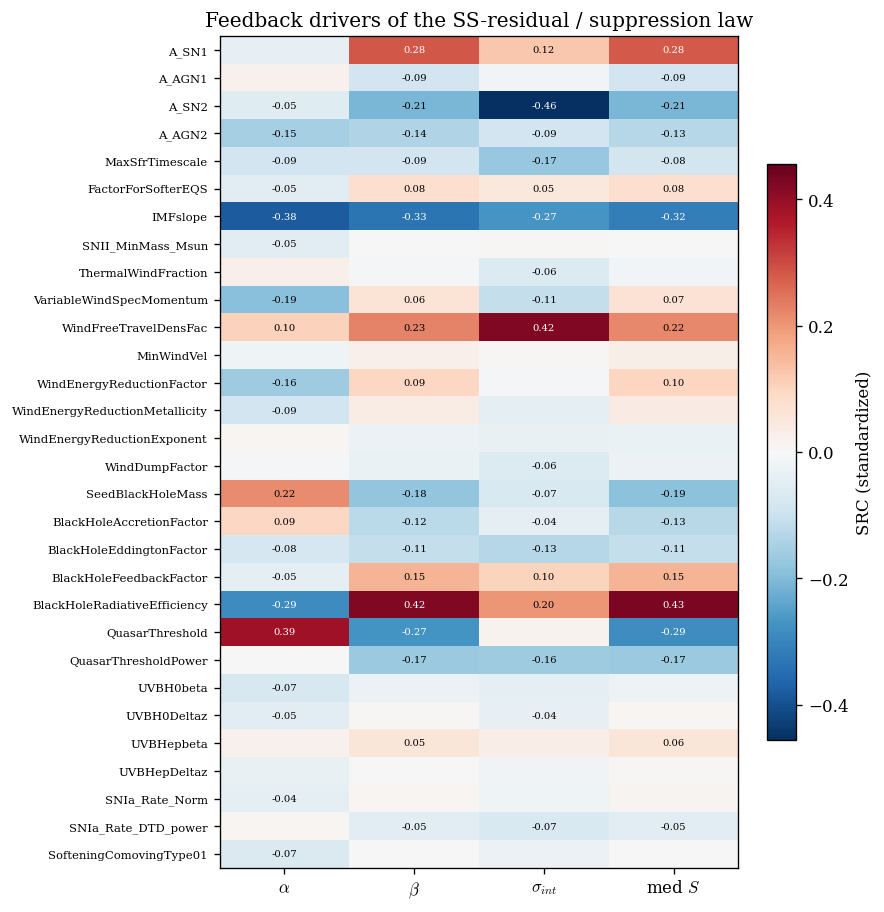

In [5]:
vmax = np.nanmax(np.abs(SRC))
fig, ax = plt.subplots(figsize=(6.2, 9))
im = ax.imshow(SRC, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(TARGETS)))
ax.set_xticklabels([r'$\alpha$', r'$\beta$', r'$\sigma_{int}$', 'med $S$'])
ax.set_yticks(range(len(PLAB))); ax.set_yticklabels(PLAB, fontsize=7)
for i in range(len(PLAB)):
    for j in range(len(TARGETS)):
        if (SRC_lo[i, j] > 0) or (SRC_hi[i, j] < 0):
            ax.text(j, i, '%.2f' % SRC[i, j], ha='center', va='center', fontsize=6,
                    color='w' if abs(SRC[i, j]) > 0.5 * vmax else 'k')
fig.colorbar(im, ax=ax, fraction=0.05, label='SRC (standardized)')
ax.set_title('Feedback drivers of the SS-residual / suppression law')
savefig(fig, 'ss_src_heatmap'); plt.show()

wrote tsz_ss_sobol_figs/ss_top_drivers.png


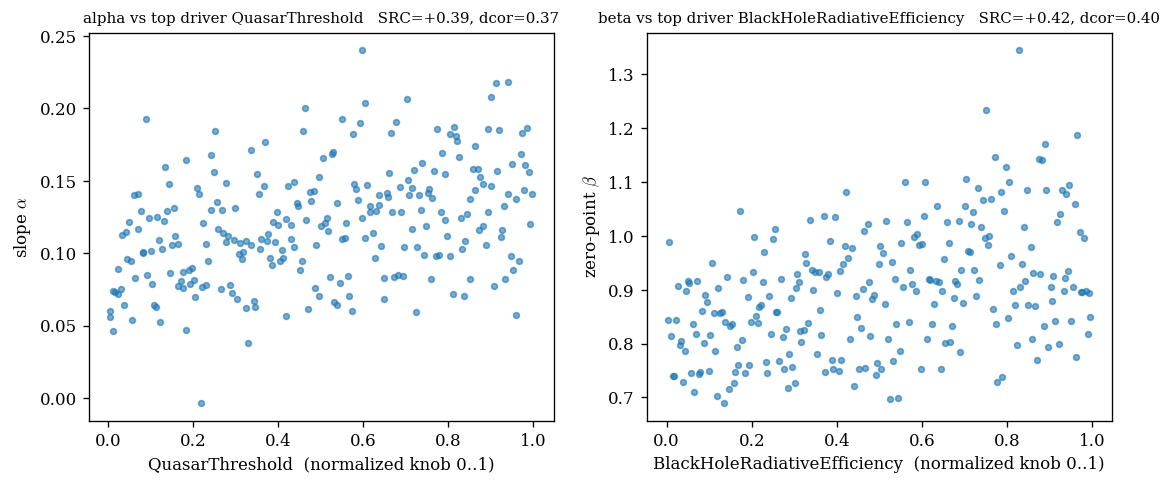

In [6]:
def top_driver(t):
    j = TARGETS.index(t)
    return int(np.nanargmax(np.abs(SRC[:, j])))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, t in zip(axes, ['alpha', 'beta']):
    i = top_driver(t); j = TARGETS.index(t)
    ax.scatter(design_norm[:, i], fit_df[t].values, s=12, c='tab:blue', alpha=0.6)
    ax.set_xlabel(f'{PLAB[i]}  (normalized knob 0..1)')
    ax.set_ylabel({'alpha': r'slope $\alpha$', 'beta': r'zero-point $\beta$'}[t])
    ax.set_title(f'{t} vs top driver {PLAB[i]}   '
                 f'SRC={SRC[i, j]:+.2f}, dcor={dcor(design_norm[:, i], fit_df[t].values):.2f}',
                 fontsize=9)
savefig(fig, 'ss_top_drivers'); plt.show()

## 4. Scorecard

In [7]:
print('=' * 72)
print('SENSITIVITY SCORECARD - drivers of the SS-residual -> suppression law')
print('=' * 72)
for j, t in enumerate(TARGETS):
    print(f'\n[{t}]   linear R2 = {R2[t]:.3f}')
    rank = np.argsort(-np.abs(SRC[:, j]))[:5]
    for i in rank:
        dc = dcor(design_norm[:, i], fit_df[t].values)
        sig = '*' if (SRC_lo[i, j] > 0 or SRC_hi[i, j] < 0) else ' '
        print(f'  {sig} {PLAB[i]:26s} SRC={SRC[i, j]:+.3f} '
              f'[{SRC_lo[i, j]:+.3f}, {SRC_hi[i, j]:+.3f}]   dcor={dc:.3f}')

SENSITIVITY SCORECARD - drivers of the SS-residual -> suppression law

[alpha]   linear R2 = 0.557
  * QuasarThreshold            SRC=+0.387 [+0.350, +0.437]   dcor=0.366
  * IMFslope                   SRC=-0.378 [-0.429, -0.333]   dcor=0.351
  * BlackHoleRadiativeEfficiency SRC=-0.287 [-0.330, -0.240]   dcor=0.294
  * SeedBlackHoleMass          SRC=+0.216 [+0.175, +0.261]   dcor=0.209
  * VariableWindSpecMomentum   SRC=-0.193 [-0.241, -0.148]   dcor=0.195

[beta]   linear R2 = 0.697
  * BlackHoleRadiativeEfficiency SRC=+0.421 [+0.383, +0.459]   dcor=0.403
  * IMFslope                   SRC=-0.335 [-0.376, -0.296]   dcor=0.396
  * A_SN1                      SRC=+0.283 [+0.249, +0.318]   dcor=0.279
  * QuasarThreshold            SRC=-0.273 [-0.312, -0.235]   dcor=0.284
  * WindFreeTravelDensFac      SRC=+0.227 [+0.187, +0.271]   dcor=0.250

[sigma_int]   linear R2 = 0.644
  * A_SN2                      SRC=-0.457 [-0.495, -0.418]   dcor=0.476
  * WindFreeTravelDensFac      SRC=+0.424 [+

## 5. Alternative visual lenses

The same Sobol cube can be viewed from three complementary perspectives:

1. A **phase diagram** in calibration-parameter space ($\alpha$ vs $\beta$), colored by intrinsic scatter $\sigma_{\rm int}$.
2. **Tornado plots** showing the strongest signed drivers for each target with bootstrap uncertainty bars.
3. A **PCA map** of the 30-D feedback cube to reveal large-scale gradients in fitted calibration parameters.

These answer different questions:
- Where do design points live globally? (phase diagram)
- Which knobs matter most, and with what sign? (tornado)
- Are responses smooth or fragmented in parameter space? (PCA landscape)

wrote tsz_ss_sobol_figs/ss_phase_diagram.png


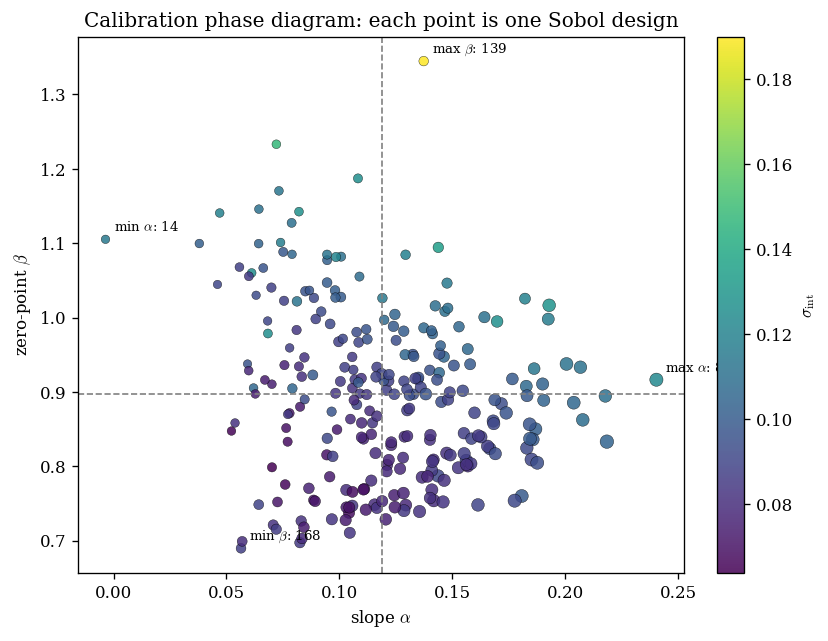

In [8]:
# 5a) Global phase diagram of design-level calibration behavior
alpha = fit_df['alpha'].values.astype(float)
beta = fit_df['beta'].values.astype(float)
sig = fit_df['sigma_int'].values.astype(float)
rho = fit_df['spearman'].values.astype(float)

m = np.isfinite(alpha) & np.isfinite(beta) & np.isfinite(sig) & np.isfinite(rho)
a, b, s, r = alpha[m], beta[m], sig[m], rho[m]

sizes = 25 + 140 * np.clip(np.abs(r), 0, 1) ** 1.5
fig, ax = plt.subplots(figsize=(7.2, 5.8))
sc = ax.scatter(a, b, c=s, s=sizes, cmap='viridis', alpha=0.85, edgecolor='k', linewidth=0.25)

ax.axvline(np.nanmedian(a), color='0.5', lw=1, ls='--')
ax.axhline(np.nanmedian(b), color='0.5', lw=1, ls='--')
ax.set_xlabel(r'slope $\alpha$')
ax.set_ylabel(r'zero-point $\beta$')
ax.set_title(r'Calibration phase diagram: each point is one Sobol design')
fig.colorbar(sc, ax=ax, fraction=0.045, label=r'$\sigma_{\rm int}$')

# Annotate extreme designs for quick orientation.
i_min_a = int(np.nanargmin(alpha))
i_max_a = int(np.nanargmax(alpha))
i_min_b = int(np.nanargmin(beta))
i_max_b = int(np.nanargmax(beta))
for name, d in [('min $\\alpha$', i_min_a), ('max $\\alpha$', i_max_a),
                ('min $\\beta$', i_min_b), ('max $\\beta$', i_max_b)]:
    ax.annotate(f'{name}: {d}', (alpha[d], beta[d]), xytext=(5, 5),
                textcoords='offset points', fontsize=8)

savefig(fig, 'ss_phase_diagram'); plt.show()

wrote tsz_ss_sobol_figs/ss_tornado_drivers.png


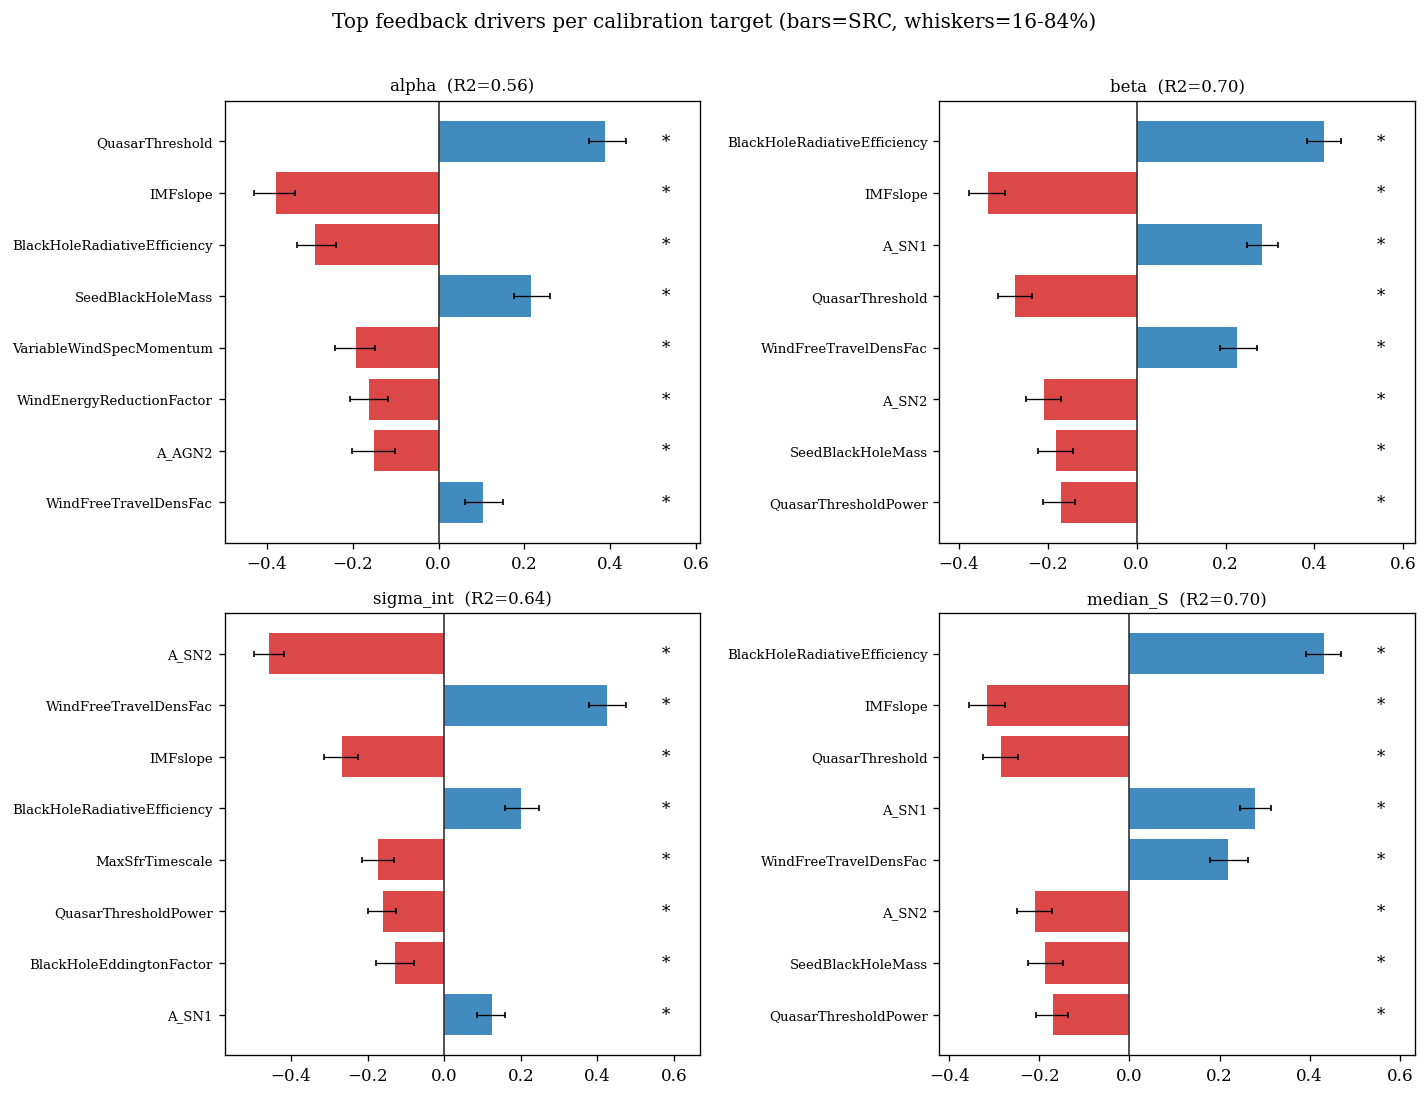

In [9]:
# 5b) Tornado-style sensitivity summaries (top signed drivers per target)
def tornado_one(ax, target, topn=8):
    j = TARGETS.index(target)
    valid = np.isfinite(SRC[:, j]) & np.isfinite(SRC_lo[:, j]) & np.isfinite(SRC_hi[:, j])
    idx = np.where(valid)[0]
    rank = idx[np.argsort(-np.abs(SRC[idx, j]))[:topn]]

    vals = SRC[rank, j]
    lo = SRC_lo[rank, j]
    hi = SRC_hi[rank, j]
    names = [PLAB[i] for i in rank]
    y = np.arange(len(rank))

    colors = np.where(vals >= 0, '#1f77b4', '#d62728')
    ax.barh(y, vals, color=colors, alpha=0.85)
    xerr = np.vstack([vals - lo, hi - vals])
    ax.errorbar(vals, y, xerr=xerr, fmt='none', ecolor='k', elinewidth=0.8, capsize=2)
    ax.axvline(0, color='0.2', lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'{target}  (R2={R2[target]:.2f})', fontsize=10)

    xmin = float(np.nanmin(lo))
    xmax = float(np.nanmax(hi))
    pad = 0.08 * (xmax - xmin + 1e-12)
    ax.set_xlim(xmin - pad, xmax + 2.5 * pad)

    sig_mask = (lo > 0) | (hi < 0)
    x_star = xmax + 1.2 * pad
    for yy, is_sig in zip(y, sig_mask):
        if is_sig:
            ax.text(x_star, yy, '*', va='center', ha='left', fontsize=10)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False)
for ax, t in zip(axes.ravel(), TARGETS):
    tornado_one(ax, t, topn=8)
fig.suptitle('Top feedback drivers per calibration target (bars=SRC, whiskers=16-84%)', y=1.01)
fig.tight_layout()
savefig(fig, 'ss_tornado_drivers'); plt.show()

wrote tsz_ss_sobol_figs/ss_pca_landscape.png


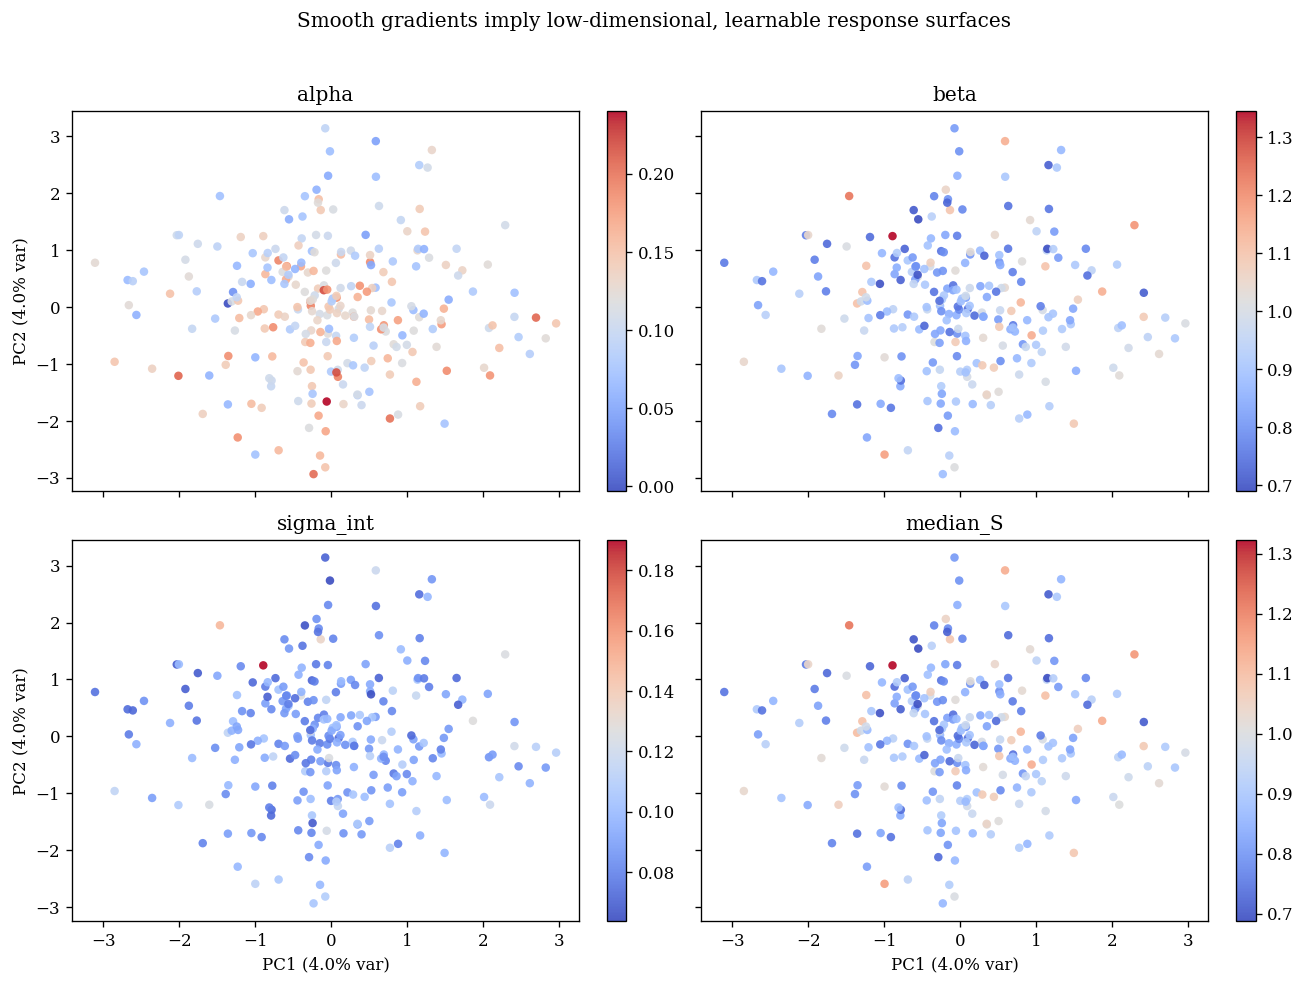

In [10]:
# 5c) PCA map of 30-D feedback space colored by calibration outputs
X = np.asarray(design_norm, float)
Xm = np.nanmean(X, axis=0, keepdims=True)
Xs = np.nanstd(X, axis=0, keepdims=True) + 1e-12
Xz = np.nan_to_num((X - Xm) / Xs, nan=0.0)

U, Svals, Vt = np.linalg.svd(Xz, full_matrices=False)
PC = Xz @ Vt[:2].T
var = (Svals ** 2) / np.sum(Svals ** 2)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, t in zip(axes.ravel(), TARGETS):
    c = fit_df[t].values.astype(float)
    sc = ax.scatter(PC[:, 0], PC[:, 1], c=c, cmap='coolwarm', s=26, alpha=0.9, edgecolor='none')
    ax.set_title(t)
    fig.colorbar(sc, ax=ax, fraction=0.046)

axes[1, 0].set_xlabel(f'PC1 ({100 * var[0]:.1f}% var)')
axes[1, 1].set_xlabel(f'PC1 ({100 * var[0]:.1f}% var)')
axes[0, 0].set_ylabel(f'PC2 ({100 * var[1]:.1f}% var)')
axes[1, 0].set_ylabel(f'PC2 ({100 * var[1]:.1f}% var)')
fig.suptitle('Smooth gradients imply low-dimensional, learnable response surfaces', y=1.02)
fig.tight_layout()
savefig(fig, 'ss_pca_landscape'); plt.show()

## 6. What is the point of this notebook?

This notebook is not just fitting lines; it tests whether a physically motivated **one-number halo summary**,
$\Delta_{\rm SS}$, remains predictive for matter suppression across feedback space.

Core purpose:
1. **Compression:** Reduce complex baryonic effects to a low-dimensional calibration law $(\alpha,\beta,\sigma_{\rm int})$.
2. **Control knobs:** Identify which feedback parameters tilt the law (change $\alpha$), shift it (change $\beta$), or add stochasticity ($\sigma_{\rm int}$).
3. **Transferability check:** Determine whether a measured tSZ residual can forecast small-scale suppression away from one fiducial model.
4. **Practical outcome:** Build interpretable priors for baryonic uncertainty in weak-lensing and clustering analyses.

Interpretation guide:
- Smooth maps with a few dominant drivers mean the calibration is actionable.
- Fragmented maps or large $\sigma_{\rm int}$ mean $\Delta_{\rm SS}$ is a weaker transport statistic.

In [11]:
# 6a) Quick numerical takeaway table
rows = []
for t in TARGETS:
    j = TARGETS.index(t)
    y = fit_df[t].values.astype(float)
    sig_frac = np.mean((SRC_lo[:, j] > 0) | (SRC_hi[:, j] < 0))
    rows.append({
        'target': t,
        'median': float(np.nanmedian(y)),
        'p16': float(np.nanpercentile(y, 16)),
        'p84': float(np.nanpercentile(y, 84)),
        'linear_R2': float(R2[t]),
        'significant_driver_fraction': float(sig_frac),
    })

summary_df = pd.DataFrame(rows)
display(summary_df)

,target,median,p16,p84,linear_R2,significant_driver_fraction
0,alpha,0.118804,0.078646,0.157884,0.557494,0.666667
1,beta,0.896586,0.770126,1.015823,0.697476,0.633333
2,sigma_int,0.089159,0.078018,0.105679,0.644256,0.600000
3,median_S,0.881887,0.764558,0.999857,0.695616,0.633333


## 7. From a per-halo law to an observable-conditioned suppression prior

Sections 1–4 fit the **per-halo** money plot inside each feedback model: how well one halo's
self-similar residual $\Delta_{\rm SS}$ predicts *its own* suppression. That slope is weak
(median Spearman $\rho\simeq0.24$) — but it is also **not the quantity a survey measures.**
Matter-power suppression is a population statistic, and what tSZ / X-ray surveys actually
constrain is a *population mean*: the stacked $Y$–$M$ amplitude, or the mean group gas fraction
$f_{\rm gas}$.

So here we change the question. For each Sobol design we collapse the 1111 halos to the
**population observables** a survey could measure, and ask whether *those* predict the design's
mean suppression. The motivating context: baryonic feedback suppresses $P(k)$ by $\sim$10–30%
at $k\sim1$–$10\,h/$Mpc — the dominant astrophysical systematic for Stage-IV weak lensing
(Rubin/LSST, Euclid, Roman). If a measurable thermodynamic observable forecasts that
suppression, the deliverable is an **observable-conditioned prior**: measure $f_{\rm gas}$ (or
the $Y$–$M$ amplitude) $\Rightarrow$ forecast $P_{\rm hydro}/P_{\rm DMO}$ with a calibrated
uncertainty, replacing an uninformative marginalization over feedback.

In [12]:
# 7.0 Collapse each design's 1111 halos to the population observables a survey measures
iFG = OBS_NAMES.index('f_gas'); iSp = OBS_NAMES.index('supp_prof')

logc0_d = np.full(n_design, np.nan)   # Y-M amplitude (self-similar normalization)
fgas_d  = np.full(n_design, np.nan)   # median halo gas fraction (<R200)
supp_d  = np.full(n_design, np.nan)   # median P_hydro/P_DMO at k~10.4 (Fourier)
suppP_d = np.full(n_design, np.nan)   # median profile-ratio suppression (0.1-0.5 R200)
for d in range(n_design):
    Y = OBS[d, :, iY]
    base = np.isfinite(logM) & np.isfinite(Y) & (Y > 0)
    logc0_d[d] = np.mean(np.log10(Y[base]) - (5 / 3) * logM[base])
    fgas_d[d]  = np.nanmedian(OBS[d, :, iFG])
    supp_d[d]  = np.nanmedian(OBS[d, :, iS])
    suppP_d[d] = np.nanmedian(OBS[d, :, iSp])
dY = logc0_d - np.median(logc0_d)     # Y-M amplitude relative to the design median

print(f'Population spread across {n_design} designs:')
print(f'  Y-M amplitude  d_logc0  range [{dY.min():+.3f}, {dY.max():+.3f}]')
print(f'  median f_gas            range [{fgas_d.min():.3f}, {fgas_d.max():.3f}]')
print(f'  median supp (k~10.4)    range [{supp_d.min():.3f}, {supp_d.max():.3f}]')
print(f'  median supp (profile)   range [{suppP_d.min():.3f}, {suppP_d.max():.3f}]')
print('\nPopulation predictiveness (Spearman across designs) -- cf. per-halo rho~0.24:')
for slab, s in [('supp k~10.4', supp_d), ('supp profile', suppP_d)]:
    print(f'  {slab:13s} vs f_gas: {spearmanr(fgas_d, s).correlation:+.3f}'
          f'   vs Y-M amp: {spearmanr(dY, s).correlation:+.3f}')

Population spread across 256 designs:
  Y-M amplitude  d_logc0  range [-0.468, +0.086]
  median f_gas            range [0.060, 0.161]
  median supp (k~10.4)    range [0.688, 1.322]
  median supp (profile)   range [0.885, 1.036]

Population predictiveness (Spearman across designs) -- cf. per-halo rho~0.24:
  supp k~10.4   vs f_gas: +0.516   vs Y-M amp: +0.533
  supp profile  vs f_gas: +0.814   vs Y-M amp: +0.845


### 7.1 The population calibration

Across the 256 designs the median suppression tracks both the population gas fraction and the
$Y$–$M$ amplitude with Spearman $\rho\simeq0.5$ (Fourier $k\approx10.4$) to $\rho\simeq0.85$
(profile ratio) — i.e. the *population* observable is **3–4$\times$ more predictive** than the
per-halo $\Delta_{\rm SS}$ slope ($\rho\simeq0.24$). The two suppression metrics — the Fourier
ratio at $k\approx10.4$ (the $P(k)$ analog, noisier on a single 6.25 Mpc/h patch) and the
configuration-space profile ratio over $0.1$–$0.5\,R_{200}$ (tighter) — tell the same story.
The red band is the $\pm1\sigma_{\rm pred}$ prior (MLE fit with intrinsic scatter); dashed lines
mark the van Daalen+20 TNG/EAGLE/BAHAMAS values at $k=10$.

wrote tsz_ss_sobol_figs/ss_population_prior.png


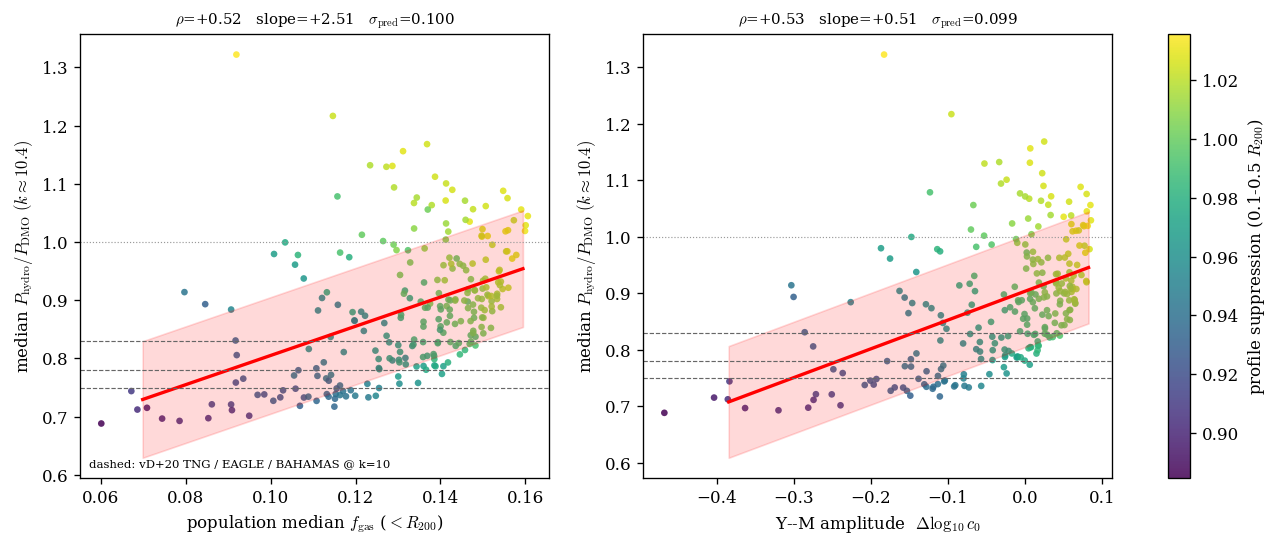

In [13]:
# 7.1 Population calibration: mean suppression vs observable, with a prior band
def fit_prior(x, y):
    """MLE line y = a*x + b with intrinsic (prediction) scatter sigma."""
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    def nll(th):
        a, b, ls = th; s2 = np.exp(2 * ls); r = y - (a * x + b)
        return 0.5 * np.sum(np.log(2 * np.pi * s2) + r * r / s2)
    a0, b0 = np.polyfit(x, y, 1); s0 = float(np.std(y - (a0 * x + b0))) + 1e-6
    a, b, ls = minimize(nll, [a0, b0, np.log(s0)], method='Nelder-Mead').x
    return dict(slope=float(a), intercept=float(b), sigma=float(np.exp(ls)))

# van Daalen+20 P_hydro/P_DMO at k=10 h/Mpc (matches tsz_wl_calibration LIT_SUPPRESSION)
LIT10 = {'TNG100 (vD+20)': 0.83, 'EAGLE (vD+20)': 0.78, 'BAHAMAS T7.8': 0.75}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sc = None
for ax, (x, xlab) in zip(axes, [(fgas_d, r'population median $f_{\rm gas}$ ($<R_{200}$)'),
                                (dY, r'Y--M amplitude  $\Delta\log_{10}c_0$')]):
    f = fit_prior(x, supp_d)
    sc = ax.scatter(x, supp_d, s=16, c=suppP_d, cmap='viridis', alpha=0.85, edgecolor='none')
    xs = np.linspace(np.percentile(x, 1), np.percentile(x, 99), 60)
    ys = f['slope'] * xs + f['intercept']
    ax.plot(xs, ys, 'r-', lw=2)
    ax.fill_between(xs, ys - f['sigma'], ys + f['sigma'], color='r', alpha=0.15)
    for v in LIT10.values():
        ax.axhline(v, color='0.4', lw=0.7, ls='--')
    ax.axhline(1.0, color='0.6', lw=0.7, ls=':')
    rho = spearmanr(x, supp_d).correlation
    ax.set_xlabel(xlab)
    ax.set_ylabel(r'median $P_{\rm hydro}/P_{\rm DMO}\ (k\approx10.4)$')
    ax.set_title(rf'$\rho$={rho:+.2f}   slope={f["slope"]:+.2f}   '
                 rf'$\sigma_{{\rm pred}}$={f["sigma"]:.3f}', fontsize=9)
axes[0].text(0.02, 0.02, 'dashed: vD+20 TNG / EAGLE / BAHAMAS @ k=10',
             transform=axes[0].transAxes, fontsize=7, va='bottom')
fig.colorbar(sc, ax=axes, fraction=0.025,
             label=r'profile suppression (0.1-0.5 $R_{200}$)')
savefig(fig, 'ss_population_prior'); plt.show()

### 7.2 Literature anchor — does BIND's feedback space contain the real Universe?

A calibration is only credible if the emulator's accessible suppression range *contains* the
established models. Below, the distribution of BIND design-mean suppression is compared to the
most-cited $z\sim0$ values (van Daalen, McCarthy & Schaye 2020). TNG100, EAGLE and BAHAMAS all
fall **inside** the BIND locus — the Sobol grid spans, and slightly exceeds on both sides, the
published baryonic suppression. (Per-patch $k\approx10.4$ vs full-box literature differ in
detail; $\sim10\%$ agreement is the bar, as in `tsz_wl_calibration.ipynb`.)

wrote tsz_ss_sobol_figs/ss_literature_bracket.png


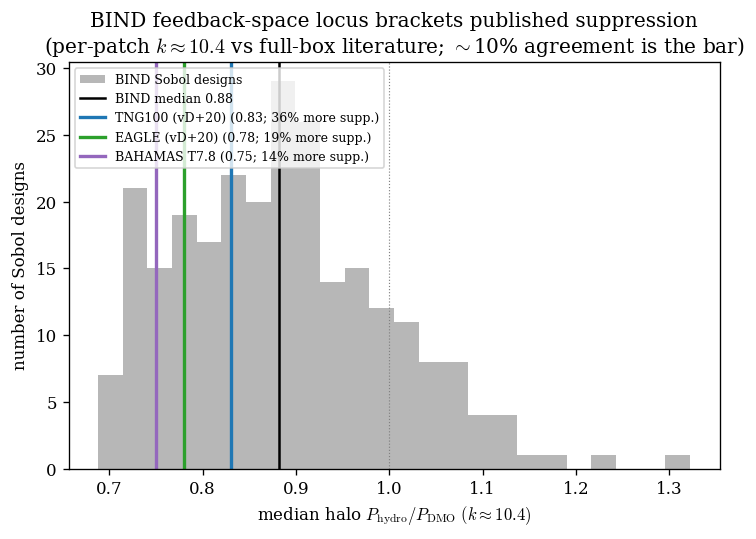

In [14]:
# 7.2 Does BIND's feedback space bracket the published suppression? (van Daalen+20)
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.hist(supp_d, bins=24, color='0.6', alpha=0.7, label='BIND Sobol designs')
ax.axvline(np.median(supp_d), color='k', lw=1.5, label=f'BIND median {np.median(supp_d):.2f}')
sty = {'TNG100 (vD+20)': 'tab:blue', 'EAGLE (vD+20)': 'tab:green', 'BAHAMAS T7.8': 'tab:purple'}
for n, v in LIT10.items():
    pct = 100 * np.mean(supp_d < v)
    ax.axvline(v, color=sty[n], lw=2, label=f'{n} ({v:.2f}; {pct:.0f}% more supp.)')
ax.axvline(1.0, color='0.5', lw=0.7, ls=':')
ax.set_xlabel(r'median halo $P_{\rm hydro}/P_{\rm DMO}\ (k\approx10.4)$')
ax.set_ylabel('number of Sobol designs')
ax.set_title('BIND feedback-space locus brackets published suppression\n'
             '(per-patch $k\\approx10.4$ vs full-box literature; $\\sim$10% agreement is the bar)')
ax.legend(fontsize=7.5, loc='upper left')
savefig(fig, 'ss_literature_bracket'); plt.show()

### 7.3 The deliverable — a suppression prior you can apply

The fitted relations invert into a usable prior: given a measured population observable,
`suppression_prior` returns the expected $P_{\rm hydro}/P_{\rm DMO}(k\approx10.4)$ with its
$1\sigma$ width $\sigma_{\rm pred}\approx0.10$. This is the actionable output of the whole
exercise — a tSZ / X-ray-informed bound on small-scale suppression, replacing an
uninformative marginalization over feedback. **Caveats:** (i) it is calibrated on
IllustrisTNG-trained BIND, so it characterizes *that model's* feedback response, not nature;
(ii) the observable must be measured in the same $<R_{200}$ aperture and mass range;
(iii) $\sigma_{\rm pred}$ is a floor — it already folds in the residual feedback freedom a
single observable cannot capture.

In [15]:
# 7.3 The deliverable: invert the calibration into an observable -> suppression prior
fit_fgas = fit_prior(fgas_d, supp_d)
fit_ym = fit_prior(dY, supp_d)

def suppression_prior(value, which='fgas'):
    """Predicted P_hydro/P_DMO(k~10.4) +/- 1 sigma for a measured population observable.
    which='fgas': value = population-median halo f_gas(<R200).
    which='ym'  : value = Y-M amplitude offset Delta log10 c0 (rel. to the design median)."""
    f = fit_fgas if which == 'fgas' else fit_ym
    return f['slope'] * value + f['intercept'], f['sigma']

print('Observable-conditioned suppression prior at k~10.4:')
print(f"  via f_gas: S = {fit_fgas['slope']:+.2f} * f_gas + {fit_fgas['intercept']:+.2f}"
      f"   +/- {fit_fgas['sigma']:.3f}")
print(f"  via Y-M  : S = {fit_ym['slope']:+.3f} * dlog10c0 + {fit_ym['intercept']:+.3f}"
      f"   +/- {fit_ym['sigma']:.3f}")
print()
rows = []
for fg in (0.06, 0.08, 0.10, 0.137, 0.16):
    mu, sg = suppression_prior(fg, 'fgas')
    rows.append({'obs_f_gas': fg, 'pred_supp': round(mu, 3), 'sigma_pred': round(sg, 3)})
    print(f'  observed median f_gas = {fg:.3f}  ->  suppression {mu:.3f} +/- {sg:.3f}')
display(pd.DataFrame(rows))

Observable-conditioned suppression prior at k~10.4:
  via f_gas: S = +2.51 * f_gas + +0.55   +/- 0.100
  via Y-M  : S = +0.509 * dlog10c0 + +0.903   +/- 0.099

  observed median f_gas = 0.060  ->  suppression 0.705 +/- 0.100
  observed median f_gas = 0.080  ->  suppression 0.755 +/- 0.100
  observed median f_gas = 0.100  ->  suppression 0.805 +/- 0.100
  observed median f_gas = 0.137  ->  suppression 0.898 +/- 0.100
  observed median f_gas = 0.160  ->  suppression 0.956 +/- 0.100


,obs_f_gas,pred_supp,sigma_pred
0,0.060,0.705,0.1
1,0.080,0.755,0.1
2,0.100,0.805,0.1
3,0.137,0.898,0.1
4,0.160,0.956,0.1
